# TensorFlow Autoencoder simple example
- from [Intro to Autoencoders](https://www.tensorflow.org/tutorials/generative/autoencoder)

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

/Users/ricky/VSCODE/timeseries_autoencoder/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
import sys
import os

sys.path.append(os.path.join('..','src'))
from timeseries_autoencoder.utils import plot_reconstruction

## Data download

In [3]:
# Download the dataset
dataframe = pd.read_csv('http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv', header=None)
raw_data = dataframe.values
dataframe.head()

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0


## Data splitting

In [4]:
# The last element contains the labels
labels = raw_data[:, -1]

# The other data points are the electrocadriogram data
data = raw_data[:, 0:-1]

train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.2, random_state=21
)

## Data normalization

In [5]:
min_val = tf.reduce_min(train_data)
max_val = tf.reduce_max(train_data)

train_data = (train_data - min_val) / (max_val - min_val)
test_data = (test_data - min_val) / (max_val - min_val)

train_data = tf.cast(train_data, tf.float32)
test_data = tf.cast(test_data, tf.float32)

## Nominal / Anomalous data separation

In [6]:
train_labels = train_labels.astype(bool)
test_labels = test_labels.astype(bool)

normal_train_data = train_data[train_labels]
normal_test_data = test_data[test_labels]

anomalous_train_data = train_data[~train_labels]
anomalous_test_data = test_data[~test_labels]

### Plot a normal vs anomalous ECG

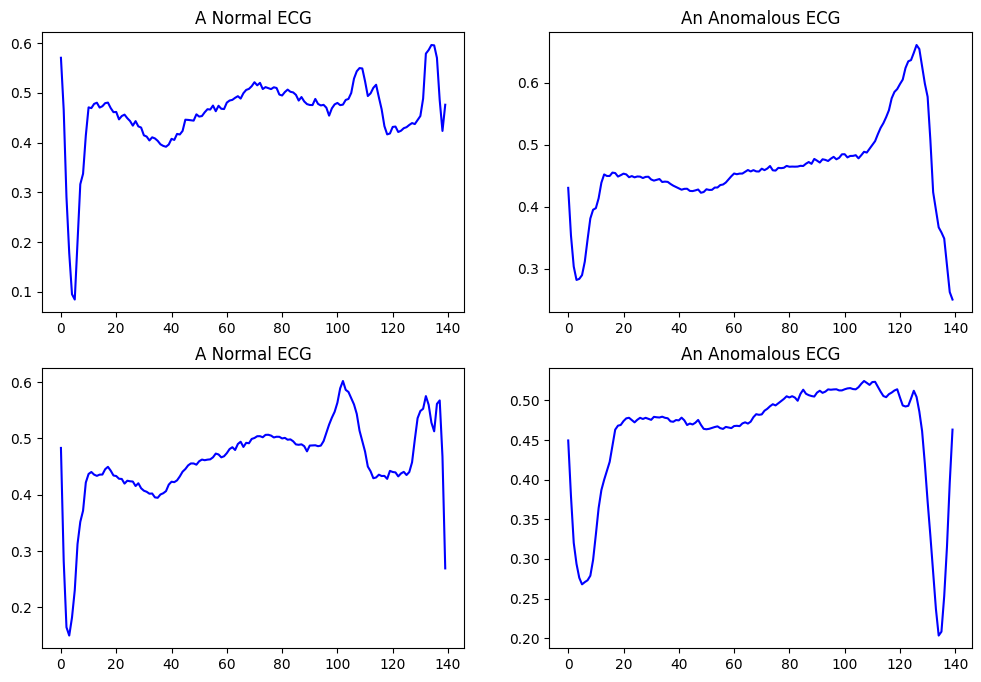

In [7]:
samples = 2
fig, axes = plt.subplots(samples, 2, figsize=(12,4*samples), squeeze = False)

for s in range(samples):
    plot_reconstruction(normal_train_data[s], axes[s][0]).set_title("A Normal ECG")
    plot_reconstruction(anomalous_train_data[s], axes[s][1]).set_title("An Anomalous ECG")


In [8]:
from tensorflow.keras.models import Model
from tensorflow.keras import layers

class AnomalyDetector(Model):
  def __init__(self):
    super(AnomalyDetector, self).__init__()
    self.encoder = tf.keras.Sequential([
      layers.Dense(32, activation="relu"),
      layers.Dense(16, activation="relu"),
      layers.Dense(8, activation="relu")])

    self.decoder = tf.keras.Sequential([
      layers.Dense(16, activation="relu"),
      layers.Dense(32, activation="relu"),
      layers.Dense(140, activation="sigmoid")])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = AnomalyDetector()

In [9]:
autoencoder.compile(optimizer='adam', loss='mae')

history = autoencoder.fit(
    normal_train_data,
    normal_train_data,
    epochs=20,
    batch_size=512,
    validation_data=(test_data, test_data),
    shuffle=True
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0574 - val_loss: 0.0529
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0554 - val_loss: 0.0515
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0528 - val_loss: 0.0502
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0498 - val_loss: 0.0482
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0467 - val_loss: 0.0464
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0434 - val_loss: 0.0446
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0403 - val_loss: 0.0430
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0375 - val_loss: 0.0416
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0350 - val_loss: 0.0404
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0329 - val_loss: 0.0394
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0312 - val_loss: 0.0385
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0297 - val_loss: 0.0378
Epoch 13/20


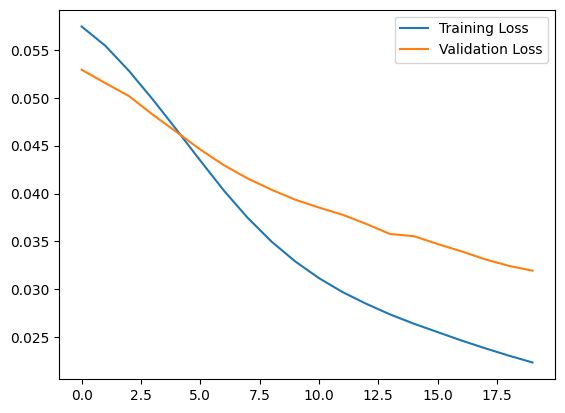

In [10]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()

In [11]:
normal_test_encoded = autoencoder.encoder(normal_test_data).numpy()
normal_test_reconstructed = autoencoder.decoder(normal_test_encoded).numpy()

anomalous_test_encoded = autoencoder.encoder(anomalous_test_data).numpy()
anomalous_test_reconstructed = autoencoder.decoder(anomalous_test_encoded).numpy()

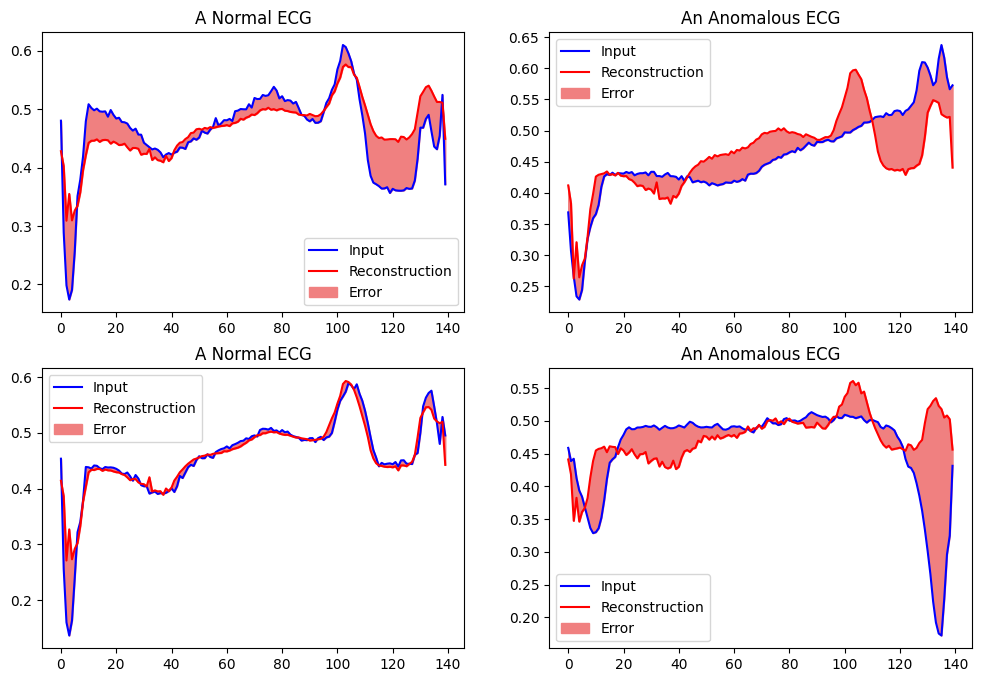

In [12]:

samples = 2
fig, axes = plt.subplots(samples, 2, figsize=(12,4*samples), squeeze = False)

for s in range(samples):

    plot_reconstruction(normal_test_data[s], axes[s][0], reconstruction=normal_test_reconstructed[s]).set_title("A Normal ECG")
    plot_reconstruction(anomalous_test_data[s], axes[s][1], reconstruction=anomalous_test_reconstructed[s]).set_title("An Anomalous ECG")


## Find anomalies

In [13]:
normal_train_reconstructed = autoencoder.predict(normal_train_data)
normal_train_loss = tf.keras.losses.mae(normal_train_reconstructed, normal_train_data).numpy()

anomalous_train_reconstructed = autoencoder.predict(anomalous_train_data)
anomalous_train_loss = tf.keras.losses.mae(anomalous_train_reconstructed, anomalous_train_data).numpy()

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 249us/step


In [14]:
threshold = np.mean(normal_train_loss) + np.std(normal_train_loss)
print("Threshold: ", threshold)

Threshold:  0.032712065


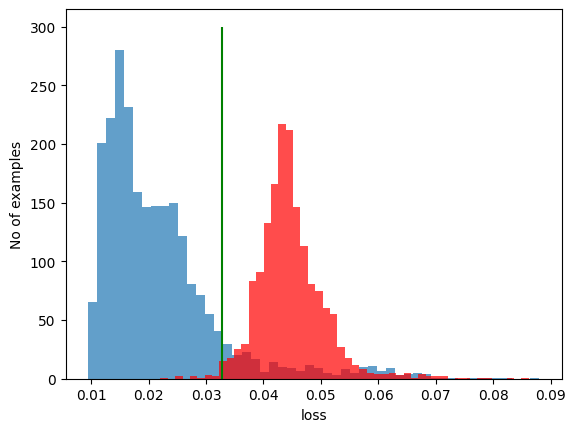

In [15]:
plt.hist(normal_train_loss, bins=50, alpha = 0.7)
plt.hist(anomalous_train_loss, bins=50, color='red', alpha=0.7)
plt.xlabel("loss")
plt.ylabel("No of examples")
plt.vlines([threshold], 0, 300, colors=['green'])

In [16]:
def predict(model, data, threshold):
  reconstructions = model(data)
  loss = tf.keras.losses.mae(reconstructions, data)
  return tf.math.less(loss, threshold)

def print_stats(predictions, labels):
  print("Accuracy = {}".format(accuracy_score(labels, predictions)))
  print("Precision = {}".format(precision_score(labels, predictions)))
  print("Recall = {}".format(recall_score(labels, predictions)))

In [17]:
preds = predict(autoencoder, test_data, threshold)
print_stats(preds, test_labels)

Accuracy = 0.94
Precision = 0.9921259842519685
Recall = 0.9
